In [1]:
import glob 

import xarray
import pandas as pd
import numpy as np

import datetime

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

# Open HSRL Files

In [ ]:
file_pattern = 'curtain_tracks/hsrl_*_curtain_CAMP2Ex.nc'
file_list = glob.glob(file_pattern)
# Open multiple NetCDF files and combine them into a single dataset
ds_obs = xarray.open_mfdataset(file_list,combine='by_coords')
ds_obs


<xarray.Dataset>
Dimensions:       (Altitude: 1058, Date: 47316)
Coordinates:
  * Altitude      (Altitude) float64 -500.0 -485.0 ... 9.483e+03 9.498e+03
  * Date          (Date) object '2019-08-24 22:08:21' ... '2019-10-05 07:18:11'
Data variables:
    hsrl_532_ext  (Date, Altitude) float64 dask.array<chunksize=(668, 1058), meta=np.ndarray>

In [3]:
# Calculate the average per altitude
average_per_altitude = ds_obs.mean(dim='Date')
std_per_altitude = ds_obs.std(dim='Date')
std_per_altitude['hsrl_532_ext']

<xarray.DataArray 'hsrl_532_ext' (Altitude: 1058)>
dask.array<_sqrt, shape=(1058,), dtype=float64, chunksize=(1058,), chunktype=numpy.ndarray>
Coordinates:
  * Altitude  (Altitude) float64 -500.0 -485.0 -470.0 ... 9.483e+03 9.498e+03

# Open the model file here.

In [ ]:
file_pattern = 'curtain_tracks/p3_2019-*curtain*.nc'
file_list = glob.glob(file_pattern)
ds_mod = xarray.open_mfdataset(file_list,combine='by_coords')
common_dates = np.intersect1d(ds_obs['Date'],ds_mod['datetime'].values)
ds_mod_ = ds_mod.sel(datetime=common_dates)
ds_mod_['datetime'] = pd.to_datetime(ds_mod_['datetime'].values)
variables = ['alt_mod', 'EXTINCT_mod']
ds_mod_ = ds_mod_[variables]
df_mod = ds_mod_.to_dataframe().reset_index()
df_mod['datetime'] = pd.to_datetime(df_mod['datetime'])
constant_altitudes = ds_obs.Altitude.values

# Create an empty DataFrame to store the resampled data
df_mod_interp = []

# Group the data by datetime
grouped = df_mod.groupby('datetime')

for name, group in grouped:
    # Sort by altitude to ensure monotonic input for interpolation
    group_sorted = group.sort_values('alt_mod')

    # Get min and max altitude for this group
    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    # Clip constant_altitudes to the valid range
    valid_altitudes = constant_altitudes[
        (constant_altitudes >= min_alt) & (constant_altitudes <= max_alt)
    ]

    # Interpolate only within the valid range
    interpolated = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])

    # Create a DataFrame for the interpolated data
    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': interpolated
    })

    df_mod_interp.append(interpolated_df)

df_mod_interp = pd.concat(df_mod_interp, ignore_index=True)
grouped_mean_ctrl = df_mod_interp.groupby('altitude').mean().reset_index()
grouped_std_ctrl = df_mod_interp.groupby('altitude').std().reset_index()

/tmp/ipykernel_697286/341103316.py:45: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_ctrl = df_mod_interp.groupby('altitude').mean().reset_index()
/tmp/ipykernel_697286/341103316.py:46: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_ctrl = df_mod_interp.groupby('altitude').std().reset_index()


In [ ]:
file_pattern = 'curtain_tracks_Exp01/p3_2019-*curtain*.nc'
file_list = glob.glob(file_pattern)
ds_mod = xarray.open_mfdataset(file_list,combine='by_coords')
common_dates = np.intersect1d(ds_obs['Date'],ds_mod['datetime'].values)
ds_mod_ = ds_mod.sel(datetime=common_dates)
ds_mod_['datetime'] = pd.to_datetime(ds_mod_['datetime'].values)
variables = ['alt_mod', 'EXTINCT_mod']
ds_mod_ = ds_mod_[variables]
df_mod = ds_mod_.to_dataframe().reset_index()
df_mod['datetime'] = pd.to_datetime(df_mod['datetime'])
constant_altitudes = ds_obs.Altitude.values

# Create an empty DataFrame to store the resampled data
df_mod_interp = []

# Group the data by datetime
grouped = df_mod.groupby('datetime')

for name, group in grouped:
    # Sort by altitude to ensure monotonic input for interpolation
    group_sorted = group.sort_values('alt_mod')

    # Get min and max altitude for this group
    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    # Clip constant_altitudes to the valid range
    valid_altitudes = constant_altitudes[
        (constant_altitudes >= min_alt) & (constant_altitudes <= max_alt)
    ]

    # Interpolate only within the valid range
    interpolated = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])

    # Create a DataFrame for the interpolated data
    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': interpolated
    })

    df_mod_interp.append(interpolated_df)

df_mod_interp = pd.concat(df_mod_interp, ignore_index=True)
grouped_mean_exp01 = df_mod_interp.groupby('altitude').mean().reset_index()
grouped_std_exp01 = df_mod_interp.groupby('altitude').std().reset_index()

/tmp/ipykernel_697286/2668388265.py:45: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_exp01 = df_mod_interp.groupby('altitude').mean().reset_index()
/tmp/ipykernel_697286/2668388265.py:46: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_exp01 = df_mod_interp.groupby('altitude').std().reset_index()


/home/svisaga/miniconda3/envs/cmp/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


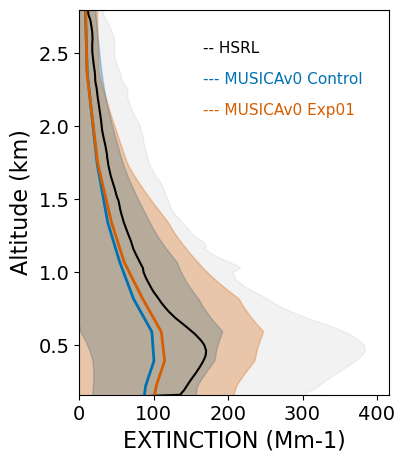

In [ ]:
fig, (ax1) = plt.subplots(
    1, 1, figsize=(4, 5)
)


ax1.plot(average_per_altitude['hsrl_532_ext']*1000, average_per_altitude['Altitude']/1000, color='k')
ax1.fill_betweenx(average_per_altitude['Altitude']/ 1000,
                  (1000)*(average_per_altitude['hsrl_532_ext'] - std_per_altitude['hsrl_532_ext']),
                 (1000)*(average_per_altitude['hsrl_532_ext'] + std_per_altitude['hsrl_532_ext']),
                  color='gray', alpha=0.1, label='Std Dev')

ax1.plot( grouped_mean_ctrl.EXTINCT_mod*1E6, grouped_mean_ctrl.altitude/1000,color='#0072B2',linewidth=2)
ax1.plot( grouped_mean_exp01.EXTINCT_mod*1E6, grouped_mean_exp01.altitude/1000,color='#D55E00',linewidth=2)
ax1.fill_betweenx(grouped_mean_ctrl.altitude/1000,
                  1E6*(grouped_mean_ctrl.EXTINCT_mod.values - grouped_std_ctrl.EXTINCT_mod.values),
                  1E6*(grouped_mean_ctrl.EXTINCT_mod.values + grouped_std_ctrl.EXTINCT_mod.values),
                  color='#0072B2', alpha=0.3, label='Std Dev')

ax1.fill_betweenx(grouped_mean_exp01.altitude/1000,
                  1E6*(grouped_mean_exp01.EXTINCT_mod.values - grouped_std_exp01.EXTINCT_mod.values),
                  1E6*(grouped_mean_exp01.EXTINCT_mod.values + grouped_std_exp01.EXTINCT_mod.values),
                  color='#D55E00', alpha=0.3, label='Std Dev')

ax1.text(0.4, 0.9, '-- HSRL', transform=ax1.transAxes, fontsize=11,
        verticalalignment='center',color='k')
ax1.text(0.4, 0.82, '--- MUSICAv0 Control', transform=ax1.transAxes, fontsize=11,
        verticalalignment='center', color='#0072B2')
ax1.text(0.4, 0.74, '--- MUSICAv0 Exp01', transform=ax1.transAxes, fontsize=11,
        verticalalignment='center', color='#D55E00')

plt.ylim(0.16,2.8)
plt.xlim(0,)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Altitude (km)', fontsize=16)
plt.xlabel('EXTINCTION (Mm-1)', fontsize=16)
plt.show()